In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading dataset
df=pd.read_csv('Dataset.csv')

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [4]:
df.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,31-12-2012,springer,2012,12,19,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,11,108,119
17375,17376,31-12-2012,springer,2012,12,20,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,8,81,89
17376,17377,31-12-2012,springer,2012,12,21,No,1,Working Day,Clear,?,0.2576,0.6,0.1642,7,83,90
17377,17378,31-12-2012,springer,2012,12,22,No,1,Working Day,Clear,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,31-12-2012,springer,2012,12,23,No,1,?,Clear,0.26,0.2727,0.65,0.1343,12,37,49


# EDA

In [5]:
#Data descriptiom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [6]:
df.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


In [7]:
df.shape

(17379, 17)

In [8]:
#converting '?' to Nan
df.replace('?',np.nan,inplace=True)

In [9]:
#converting date coulumn to datetime data type
df['dteday'] = pd.to_datetime(df['dteday'], format="%d-%m-%Y")

In [10]:
num_col=['yr','mnth','temp','atemp','hum','windspeed','casual','registered']
for col in num_col:
    df[col] = pd.to_numeric(df[col])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17373 non-null  object        
 3   yr          17378 non-null  float64       
 4   mnth        17378 non-null  float64       
 5   hr          17379 non-null  int64         
 6   holiday     17378 non-null  object        
 7   weekday     17379 non-null  int64         
 8   workingday  17374 non-null  object        
 9   weathersit  17375 non-null  object        
 10  temp        17368 non-null  float64       
 11  atemp       17373 non-null  float64       
 12  hum         17373 non-null  float64       
 13  windspeed   17374 non-null  float64       
 14  casual      17378 non-null  float64       
 15  registered  17378 non-null  float64       
 16  cnt         17379 non-

In [12]:
df.describe()

,instant,dteday,yr,mnth,hr,weekday,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17378.000000,17378.000000,17379.000000,17379.000000,17368.000000,17373.000000,17373.000000,17374.000000,17378.000000,17378.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2011.502589,6.537461,11.546752,3.003683,0.497132,0.475851,0.627208,0.190080,35.676603,153.792554,189.463088
min,1.0000,2011-01-01 00:00:00,2011.000000,1.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2011.000000,4.000000,6.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,2012.000000,7.000000,12.000000,3.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,2012.000000,10.000000,18.000000,5.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,2012.000000,12.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,0.500008,3.438625,6.914405,2.005771,0.192525,0.171829,0.192939,0.122321,49.306423,151.359786,181.387599


In [13]:
df.isna().sum()

instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64

In [14]:
# %of missing values
for i in df.isna().sum():
  print((i/len(df))*100)

0.0
0.0
0.03452442603141723
0.005754071005236205
0.005754071005236205
0.0
0.005754071005236205
0.0
0.028770355026181024
0.02301628402094482
0.06329478105759825
0.03452442603141723
0.03452442603141723
0.028770355026181024
0.005754071005236205
0.005754071005236205
0.0


In [15]:
# 0 to 5 % missing values: drop rows
# 6 to 45 %: replace the missing values
# 50%: drop column

In [16]:
# Dropping null values
df = df.dropna()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(17339, 17)

In [19]:
df.reset_index(drop=True,inplace=True)

In [20]:
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,springer,2011.0,1.0,0,No,6,No work,Clear,0.24,0.2879,0.81,0.0000,3.0,13.0,16
1,2,2011-01-01,springer,2011.0,1.0,1,No,6,No work,Clear,0.22,0.2727,0.80,0.0000,8.0,32.0,40
2,4,2011-01-01,springer,2011.0,1.0,3,No,6,No work,Clear,0.24,0.2879,0.75,0.0000,3.0,10.0,13
3,5,2011-01-01,springer,2011.0,1.0,4,No,6,No work,Clear,0.24,0.2879,0.75,0.0000,0.0,1.0,1
4,6,2011-01-01,springer,2011.0,1.0,5,No,6,No work,Mist,0.24,0.2576,0.75,0.0896,0.0,1.0,1
5,8,2011-01-01,springer,2011.0,1.0,7,No,6,No work,Clear,0.20,0.2576,0.86,0.0000,1.0,2.0,3
6,9,2011-01-01,springer,2011.0,1.0,8,No,6,No work,Clear,0.24,0.2879,0.75,0.0000,1.0,7.0,8
7,11,2011-01-01,springer,2011.0,1.0,10,No,6,No work,Clear,0.38,0.3939,0.76,0.2537,12.0,24.0,36
8,14,2011-01-01,springer,2011.0,1.0,13,No,6,No work,Mist,0.46,0.4545,0.72,0.2985,47.0,47.0,94
9,15,2011-01-01,springer,2011.0,1.0,14,No,6,No work,Mist,0.46,0.4545,0.72,0.2836,35.0,71.0,106


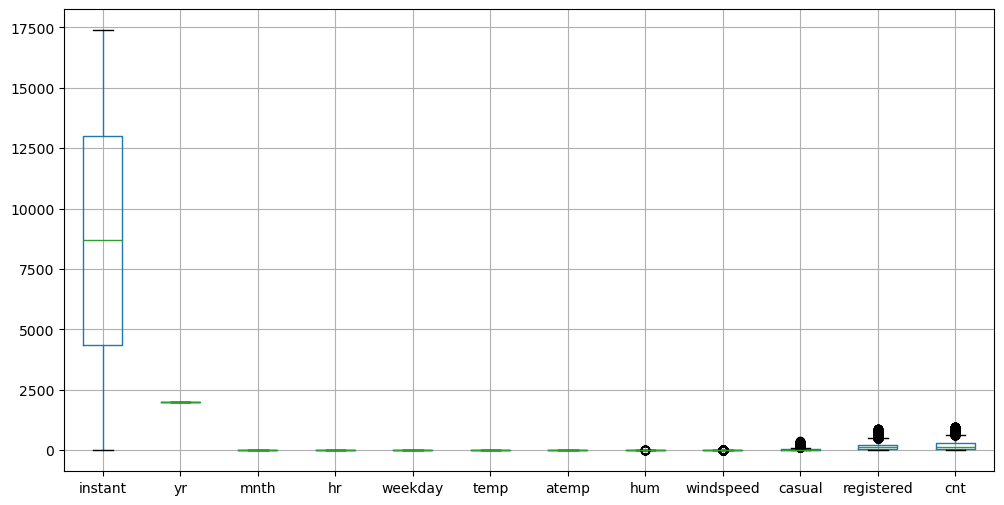

In [21]:
#Outliers Detection
plt.figure(figsize=(12,6))
df.boxplot()
plt.show()

# Data Visualization

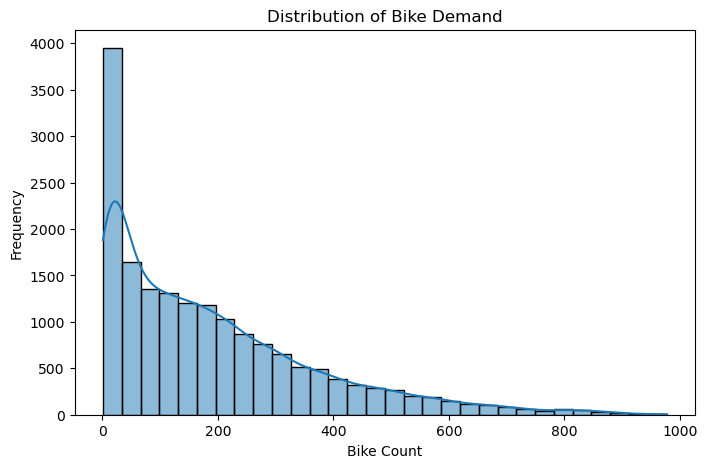

In [22]:
#Check how bike demand is distributed:
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], kde=True, bins=30)
plt.title('Distribution of Bike Demand')
plt.xlabel('Bike Count')
plt.ylabel('Frequency')
plt.show()

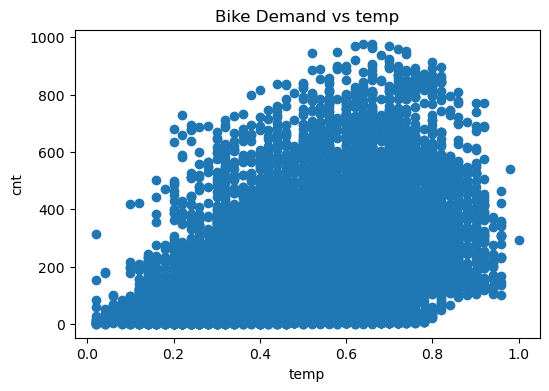

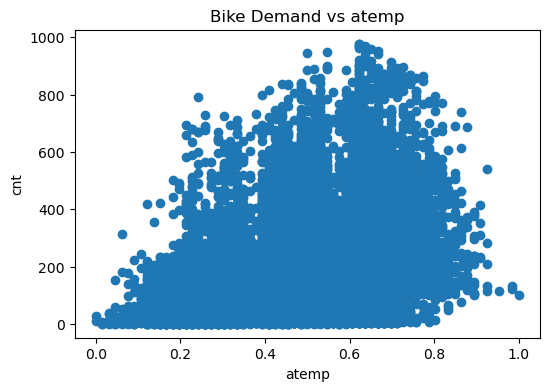

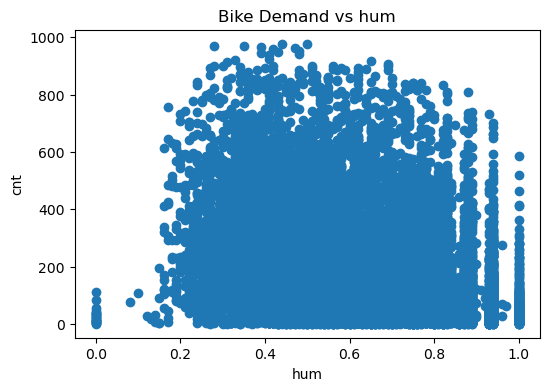

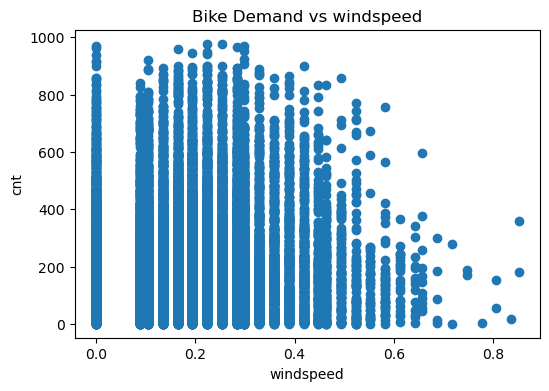

In [23]:
#To understand how continuous features like temperature, humidity, windspeed affect bike demand
for col in ['temp', 'atemp', 'hum', 'windspeed']:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df['cnt'])
    plt.title(f'Bike Demand vs {col}')
    plt.xlabel(col)
    plt.ylabel('cnt')
    plt.show()
#Temperature & atemp-As temperature increases, bike demand generally increases
#Humidity-Higher humidity slightly reduces bike demand
#Windspeed-Very high windspeed reduces bike usage

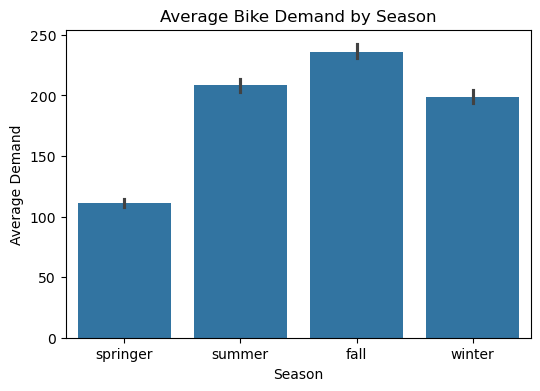

In [24]:
#Bike Demand by Season
plt.figure(figsize=(6,4))
sns.barplot(x='season',y='cnt',data=df)
plt.title('Average Bike Demand by Season')
plt.xlabel('Season')
plt.ylabel('Average Demand')
plt.show()
#fall-highest demand
#Spring-lower demand

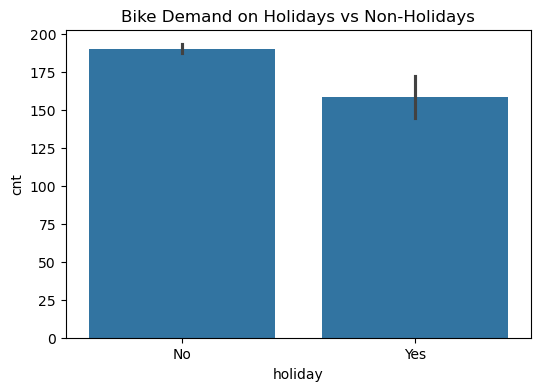

In [25]:
#Bike Demand on Holidays
plt.figure(figsize=(6,4))
sns.barplot(x='holiday', y='cnt', data=df)
plt.title('Bike Demand on Holidays vs Non-Holidays')
plt.show()
#Demand is lower on holidays

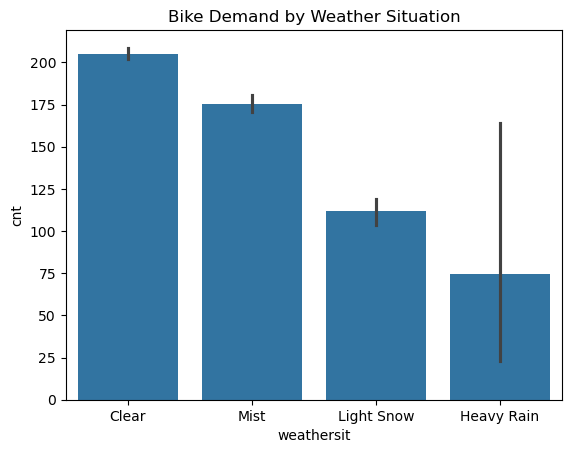

In [26]:
#Weather
sns.barplot(x='weathersit', y='cnt', data=df)
plt.title('Bike Demand by Weather Situation')
plt.show()
#Clear drop in demand during bad weather

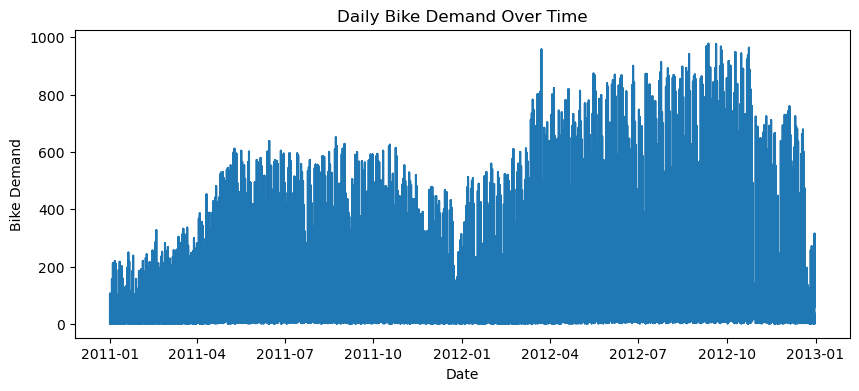

In [27]:
#To observe demand trends over time
plt.figure(figsize=(10,4))
plt.plot(df['dteday'], df['cnt'])
plt.title('Daily Bike Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Bike Demand')
plt.show()
#Upward trend over time growing adoption of bike rentals
#Seasonal spikes visible every year
#Confirms bike demand is time-dependent

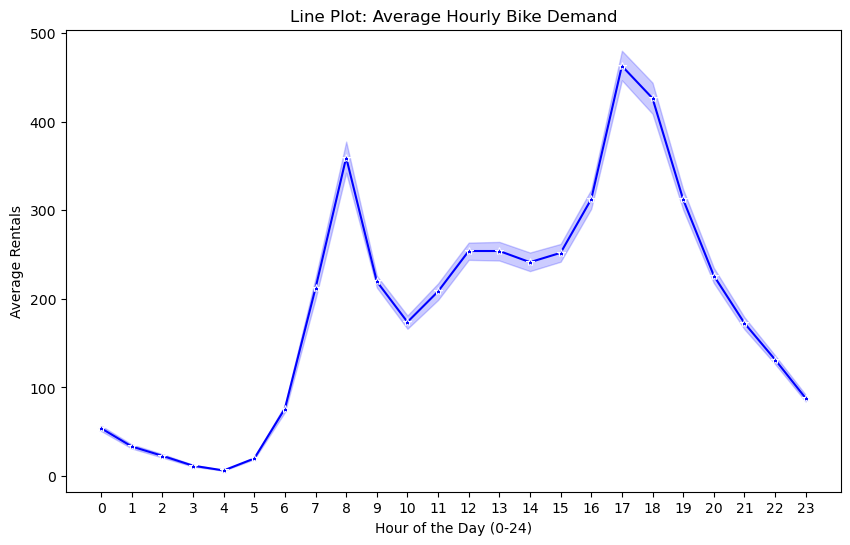

In [28]:
#To identify rush hours and peak times during the day.
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='hr', y='cnt', estimator='mean', color='blue', marker='*')
plt.title('Line Plot: Average Hourly Bike Demand')
plt.xlabel('Hour of the Day (0-24)')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.show()

In [29]:
corr=df[['temp','atemp','hum','windspeed','casual','registered','cnt']].corr()

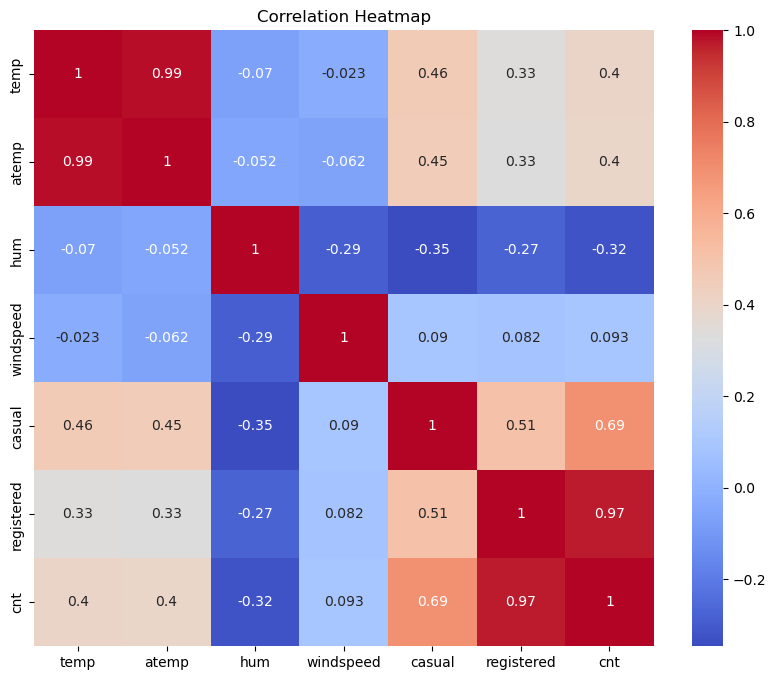

In [30]:
#To understand which variables strongly influence bike demand
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Feature Engg.

In [31]:
# Drop the redundant 'atemp' column
df = df.drop(columns=['instant','atemp','dteday','casual', 'registered'])

In [32]:
df.head(30)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,springer,2011.0,1.0,0,No,6,No work,Clear,0.24,0.81,0.0000,16
1,springer,2011.0,1.0,1,No,6,No work,Clear,0.22,0.80,0.0000,40
2,springer,2011.0,1.0,3,No,6,No work,Clear,0.24,0.75,0.0000,13
3,springer,2011.0,1.0,4,No,6,No work,Clear,0.24,0.75,0.0000,1
4,springer,2011.0,1.0,5,No,6,No work,Mist,0.24,0.75,0.0896,1
5,springer,2011.0,1.0,7,No,6,No work,Clear,0.20,0.86,0.0000,3
6,springer,2011.0,1.0,8,No,6,No work,Clear,0.24,0.75,0.0000,8
7,springer,2011.0,1.0,10,No,6,No work,Clear,0.38,0.76,0.2537,36
8,springer,2011.0,1.0,13,No,6,No work,Mist,0.46,0.72,0.2985,94
9,springer,2011.0,1.0,14,No,6,No work,Mist,0.46,0.72,0.2836,106


In [33]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [34]:
### Label Encoder
encoder = LabelEncoder()
cat_cols = ['season','yr','mnth','holiday','workingday','weathersit']

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [35]:
df.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [36]:
df

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,0,0,0,6,0,0,0.24,0.81,0.0000,16
1,1,0,0,1,0,6,0,0,0.22,0.80,0.0000,40
2,1,0,0,3,0,6,0,0,0.24,0.75,0.0000,13
3,1,0,0,4,0,6,0,0,0.24,0.75,0.0000,1
4,1,0,0,5,0,6,0,3,0.24,0.75,0.0896,1
...,...,...,...,...,...,...,...,...,...,...,...,...
17334,1,1,11,15,0,1,1,3,0.28,0.45,0.1343,315
17335,1,1,11,18,0,1,1,3,0.26,0.48,0.1343,122
17336,1,1,11,19,0,1,1,3,0.26,0.60,0.1642,119
17337,1,1,11,20,0,1,1,3,0.26,0.60,0.1642,89


# Model Building

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [38]:
# Split features and target
features= df.drop('cnt', axis=1)
target= df['cnt']

In [39]:
#train-test split
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape) 
print(y_test.shape)

(13871, 11)
(3468, 11)
(13871,)
(3468,)


In [40]:
#Decession Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [41]:
#Random Forest
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train) 

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
#Gradient Boosting Regressor
gb= GradientBoostingRegressor(random_state=42)
gb.fit(x_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Model Evaluation

In [43]:
def evaluate(model, name):
    preds = model.predict(x_test)
    print(f"\n{name}")
    print("MAE:",mean_absolute_error(y_test, preds))
    print("MSE:", mean_squared_error(y_test, preds))
    print("RMSE:",np.sqrt(mean_squared_error(y_test, preds)))
    print("R2:",r2_score(y_test, preds))

In [44]:
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")
evaluate(gb, "Gradient Boosting")


Decision Tree
MAE: 34.503892733564015
MSE: 3479.930291234141
RMSE: 58.99093397492653
R2: 0.8947427524121062

Random Forest
MAE: 26.134635524798153
MSE: 1925.9914383689447
RMSE: 43.88611897136661
R2: 0.9417446498307102

Gradient Boosting
MAE: 50.656021965109865
MSE: 5577.687665921422
RMSE: 74.68391838891036
R2: 0.8312920080328324


# Hyperparameter Tuning

In [45]:
#Decision Tree
dt_para= {'max_depth': [5, 10, 15],'min_samples_split': [2, 5, 10]}

In [46]:
dt_grid = GridSearchCV(
    dt,
    dt_para,
    cv=5,
    scoring='r2'
)

In [47]:
dt_grid.fit(x_train,y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [48]:
best_dt = dt_grid.best_estimator_
best_dt

,criterion,'squared_error'
,splitter,'best'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [49]:
#Random Forest
rf_para={'n_estimators':[100,200],'max_depth':[10,20,None]}

In [50]:
rf_grid= GridSearchCV(
    rf,
    rf_para,
    cv=3,  #cross validation repeats process 3 times
    scoring='r2',
)

In [51]:
rf_grid.fit(x_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [52]:
best_rf = rf_grid.best_estimator_
best_rf

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
#Gradient Boosting
gb_para= {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

In [54]:
gb_grid = GridSearchCV(
    gb,
    gb_para,
    cv=3,
    scoring='r2'
)

In [55]:
gb_grid.fit(x_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [56]:
best_gb = gb_grid.best_estimator_
best_gb

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [57]:
#cross validation
print("Best Decision Tree Score:", dt_grid.best_score_)
print("Best Random Forest Score:", rf_grid.best_score_)
print("Best Gradient Boosting Score:", gb_grid.best_score_)

Best Decision Tree Score: 0.902184501626771
Best Random Forest Score: 0.9335168306438448
Best Gradient Boosting Score: 0.9410254805069331


In [58]:
best_dtmodel = dt_grid.best_estimator_
evaluate(best_dtmodel, "Tuned Decision Tree")


Tuned Decision Tree
MAE: 33.624238241055835
MSE: 3246.7288947582347
RMSE: 56.98007454152929
R2: 0.901796381385232


In [59]:
best_rfmodel = rf_grid.best_estimator_
evaluate(best_rfmodel, "Tuned Random Forest")


Tuned Random Forest
MAE: 26.102548995578623
MSE: 1915.216839101938
RMSE: 43.763190458442786
R2: 0.9420705485033256


In [60]:
best_gbmodel = gb_grid.best_estimator_
evaluate(best_gbmodel, "Tuned Gradient Boosting")


Tuned Gradient Boosting
MAE: 27.11345042369542
MSE: 1747.7129186804825
RMSE: 41.80565653928284
R2: 0.9471370297682395


In [61]:
import pickle

In [62]:
file='bike.pkl'

In [63]:
pickle.dump(best_rfmodel,open(file,'wb'))